## Environment Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS
from src.data_loader import download_dataset, list_dataset_files, load_dataset
from src.statistics import get_correlation_matrix, summarize_claims_by_group
from src.validation import (
    get_categorical_counts,
    get_duplicate_count,
    get_missing_values,
    get_numerical_validation_summary,
)
from src.visualization import (
    plot_category_distribution,
    plot_claims_by_group,
    plot_correlation_heatmap,
    plot_numeric_boxplots,
    plot_numeric_histograms,
    show_business_finding,
    show_future_work,
    show_key_insight,
    show_limitation,
)

# Life & Health Insurance Claims Analysis

**A business-oriented analysis of insurance claim severity, customer characteristics, and claim patterns**

## 1. Business Context and Analytical Scope

Insurance claim amounts can vary substantially across customers. Understanding how claim values are distributed—and whether observable customer characteristics are associated with higher claim severity—can support more informed analytical and business decisions.

The objectives of this analysis are to:

- assess the structure, quality, and limitations of the dataset;
- examine the distribution and concentration of insurance claim amounts;
- evaluate whether demographic and socioeconomic characteristics are associated with differences in claim severity;
- identify findings that may support future customer segmentation and more advanced insurance risk analysis.

### Analytical Scope

This analysis focuses on **claim severity**, represented by `Claim_Amount`.

It does not measure claim frequency, total customer risk, policy profitability, or pricing adequacy because the dataset does not include policy exposure, premium amounts, coverage limits, claim history, or repeated customer identifiers.

## 2. Dataset Overview

This project uses a synthetic dataset containing life and health insurance claim records.

Each record includes demographic information, socioeconomic characteristics, and an associated claim amount.

The dataset is intended for analytical and educational purposes and provides a controlled environment for exploring customer characteristics, claim distributions, and business insights.

### Unit of Analysis

The unit of analysis is a single insurance claim record.

Each observation is treated as an independent claim associated with one customer profile.

Because the dataset documentation is limited, this interpretation is treated as an analytical assumption rather than a confirmed business definition. Therefore, the analysis focuses on claim severity and avoids conclusions regarding claim frequency, customer lifetime value, or policy-level risk.

## 3. Data Loading
To support reproducibility, the dataset is downloaded directly from Kaggle using the `kagglehub` package.

The following steps download the dataset, list the available files, and load the insurance claims data into a pandas DataFrame.

In [2]:
# Download the latest version of the dataset
dataset_path = download_dataset()

files = list_dataset_files(dataset_path)

for file in files:
    print(file)

df = load_dataset()
df.head()

data_synthetic.csv
insurance_dataset.csv


,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount
0,59.0,Male,270727.0,Single,Master's,Doctor,3455.0
1,21.0,Female,263874.0,Single,Bachelor's,Engineer,30233.0
2,71.0,Female,48372.0,Single,Bachelor's,Engineer,340.0
3,30.0,Female,99525.0,Single,PhD,CEO,1002.0
4,64.0,Female,187038.0,Married,Master's,CEO,2828.0


## 4. Dataset Snapshot

The following metrics provide a high-level overview of the dataset before performing detailed exploratory analysis.

In [3]:
rows, columns = df.shape

print("=" * 55)
print("DATASET SNAPSHOT")
print("=" * 55)

print(f"Records               : {rows:,}")
print(f"Variables             : {columns}")
print(f"Numerical Variables   : {len(NUMERIC_COLUMNS)}")
print(f"Categorical Variables : {len(CATEGORICAL_COLUMNS)}")

print("=" * 55)

DATASET SNAPSHOT
Records               : 13,000
Variables             : 7
Numerical Variables   : 3
Categorical Variables : 4


## 5. Initial Data Understanding

Before assessing data quality or answering business questions, it is important to understand the basic structure of the dataset.

This section examines:

- the number of rows and columns;
- the available variables;
- data types;
- numerical summary statistics;
- categorical value distributions.

### Dataset Dimensions

In [4]:
rows, columns = df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 13,000
Columns: 7


### Dataset Structure and Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             13000 non-null  float64
 1   Gender          13000 non-null  str    
 2   Income          13000 non-null  float64
 3   Marital_Status  13000 non-null  str    
 4   Education       13000 non-null  str    
 5   Occupation      13000 non-null  str    
 6   Claim_Amount    13000 non-null  float64
dtypes: float64(3), str(4)
memory usage: 711.1 KB


### Numerical Summary Statistics

In [6]:
df[NUMERIC_COLUMNS].describe().round(2)

,Age,Income,Claim_Amount
count,13000.00,13000.00,13000.00
mean,51.53,161718.43,9185.65
std,20.97,99965.55,15041.94
min,18.00,5091.00,114.00
25%,34.00,75080.75,3344.75
50%,51.00,154855.50,5829.50
75%,67.00,235395.25,8293.25
max,102.42,404427.91,99841.00


### Categorical Distributions

In [7]:
categorical_counts = get_categorical_counts(df)

for column, values in categorical_counts.items():
    print(f"\n{column}")
    print("-" * 40)
    print(values)


Gender
----------------------------------------
Gender
Female    6541
Male      6459
Name: count, dtype: int64

Marital_Status
----------------------------------------
Marital_Status
Single     6513
Married    6487
Name: count, dtype: int64

Education
----------------------------------------
Education
Master's      4383
PhD           4321
Bachelor's    4296
Name: count, dtype: int64

Occupation
----------------------------------------
Occupation
CEO         10575
Engineer      633
Doctor        624
Waiter        587
Teacher       581
Name: count, dtype: int64


### Initial Observations

The dataset contains demographic, socioeconomic, and claim-related variables with appropriate numerical and categorical data types.

The categorical variables appear to be consistently encoded. However, the `Occupation` variable is highly imbalanced, with most observations belonging to the CEO category. This imbalance should be considered when interpreting occupation-level comparisons.

The initial inspection provides no immediate indication of structural problems, although formal data quality checks are required before continuing the analysis.

## 6. Data Quality Assessment

Before drawing analytical or business conclusions, the dataset must be assessed for missing values, duplicate records, invalid numerical ranges, and unusual distribution characteristics.

### Missing Values

In [8]:
get_missing_values(df)

Age               0
Gender            0
Income            0
Marital_Status    0
Education         0
Occupation        0
Claim_Amount      0
dtype: int64

### Duplicate Records

In [9]:
get_duplicate_count(df)

0

### Numerical Validation Summary

In [10]:
validation_summary = get_numerical_validation_summary(df)

validation_summary

,Minimum,Maximum,Mean,Median,Skewness
Age,18.0,102.42,51.53,51.0,0.44
Income,5091.0,404427.91,161718.43,154855.5,0.49
Claim_Amount,114.0,99841.00,9185.65,5829.5,4.06


### Validation Summary

The dataset contains no missing values or duplicate records.

The numerical variables fall within generally reasonable ranges for exploratory analysis.

The `Age` variable ranges from 18 to approximately 102 years. Although the highest values are uncommon, they are not automatically invalid and should be interpreted cautiously.

Both `Income` and `Claim_Amount` contain positive values.

`Claim_Amount` exhibits strong positive skewness, indicating that a relatively small number of large claims influence the overall distribution. This characteristic should be considered when interpreting averages.

Overall, no critical data quality issues were identified that would prevent further exploratory analysis.

## 7. Executive Summary

Before exploring the dataset in detail, the following points summarize the most important analytical findings identified throughout this analysis.

In [11]:
show_business_finding(
    "The dataset contains no missing values or duplicate records and is "
    "well suited for exploratory analysis.\n\n"
    "Claim Amount is strongly right-skewed, making the median more "
    "representative than the mean.\n\n"
    "Age and Income show only weak linear relationships with claim severity.\n\n"
    "Gender, Marital Status, and Education explain little variation in "
    "claim amounts, while Occupation shows greater variation but suffers "
    "from severe category imbalance."
)

## 8. Exploratory Data Analysis

Exploratory Data Analysis is used to understand the distributions of the numerical variables, identify unusual observations, and examine potential relationships before addressing the business questions.

### Distribution of Numerical Variables

Histograms are used to examine the shape, concentration, variability, and skewness of the numerical variables.

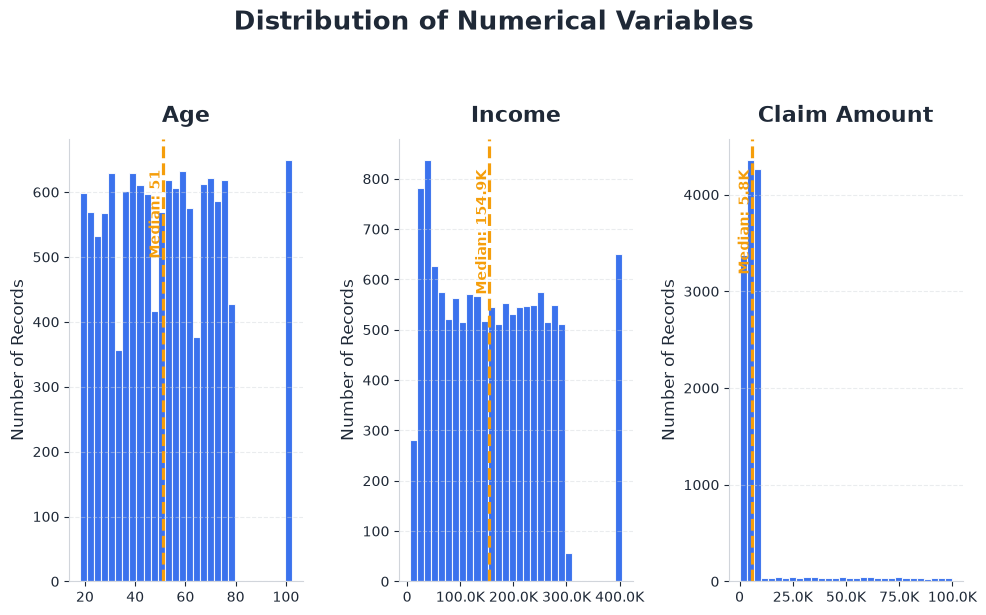

In [12]:
plot_numeric_histograms(df)

In [13]:
show_key_insight(
    "Age is relatively balanced, while Income shows moderate variation. "
    "Claim Amount is strongly right-skewed, with a small number of unusually "
    "large claims. Because of this skewness, the median is more representative "
    "of a typical claim than the mean."
)

### Boxplots of Numerical Variables

Boxplots provide a complementary view of the numerical variables by highlighting their medians, spread, and potential outliers.

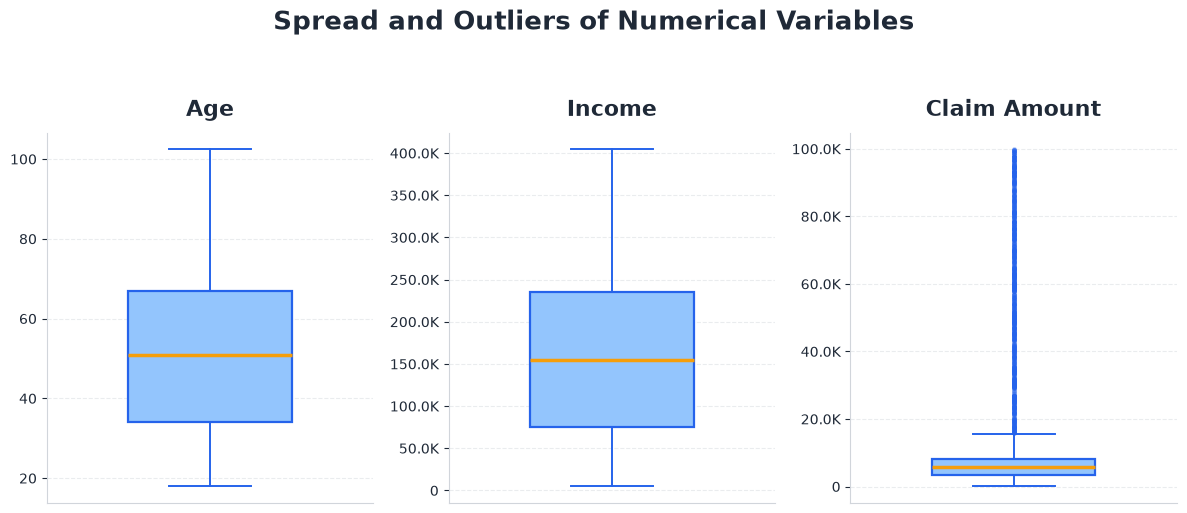

In [14]:
plot_numeric_boxplots(df)

In [15]:
show_key_insight(
    "The boxplots confirm several high observations in Age and Income, "
    "along with numerous high-value Claim Amount outliers. These large claims "
    "appear to be an inherent characteristic of the dataset rather than "
    "isolated data quality errors."
)

### Correlation Between Numerical Variables

Pearson correlation coefficients are calculated to examine the strength and direction of linear relationships among the numerical variables.

Correlation does not establish causation and may not capture nonlinear relationships.

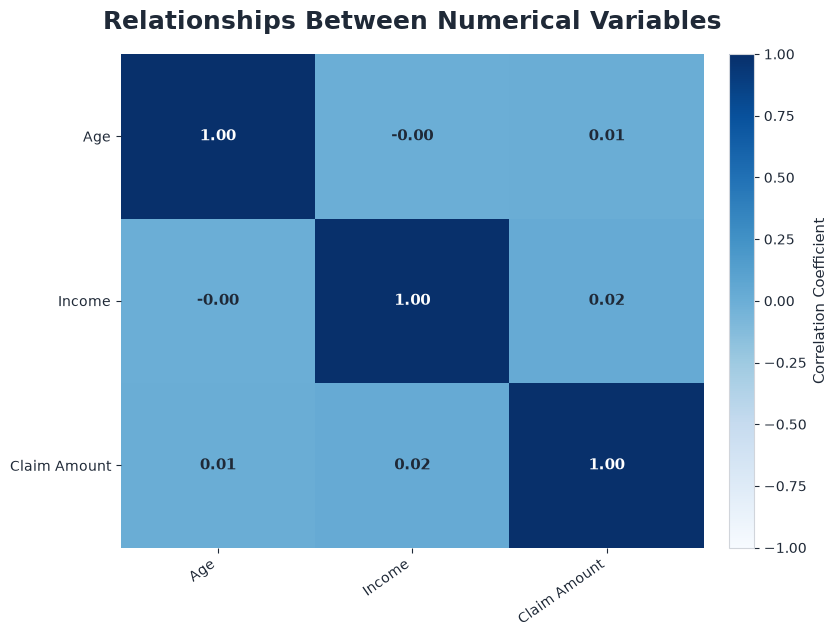

In [16]:
plot_correlation_heatmap(df)

In [17]:
show_key_insight(
    "Age, Income, and Claim Amount have relatively weak linear relationships. "
    "No single numerical variable strongly explains claim severity, so the "
    "analysis should also examine differences across categorical customer groups."
)

## 9. Customer Group Analysis

### Does claim severity differ across customer groups?

This section examines whether insurance claim amounts vary across gender, marital status, education level, and occupation.

The comparisons are descriptive and are intended to identify patterns rather than establish causal relationships.

### Claim Amount by Gender

In [18]:
summarize_claims_by_group(df, "Gender")

,count,mean,median,std
Gender,,,,
Female,6541,9237.69,5835.0,15197.71
Male,6459,9132.94,5815.0,14883.53


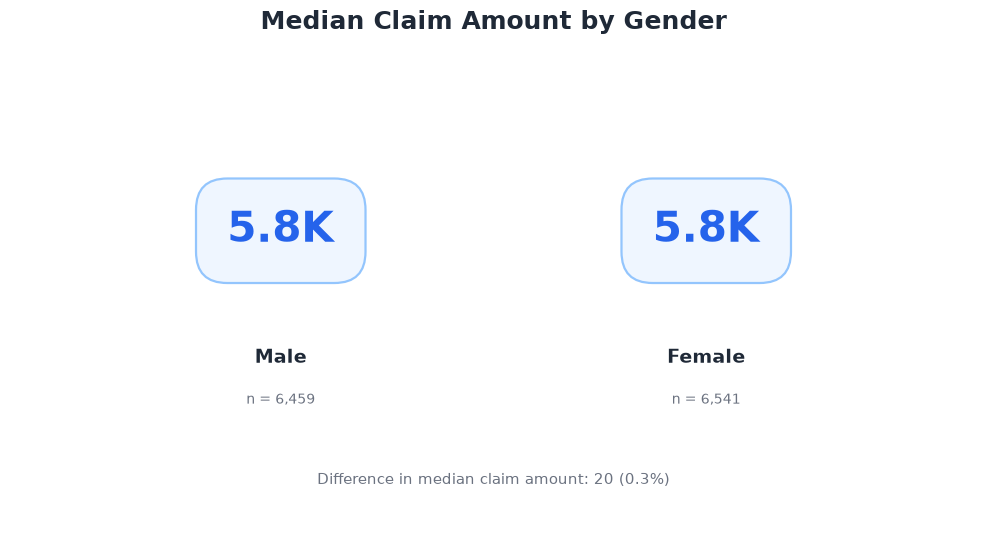

In [19]:
plot_claims_by_group(df, "Gender")

In [20]:
show_key_insight(
    "Median claim amounts are nearly identical across genders, indicating "
    "no meaningful gender-based difference in typical claim severity."
)

### Claim Amount by Marital Status

In [21]:
summarize_claims_by_group(df, "Marital_Status")

,count,mean,median,std
Marital_Status,,,,
Married,6487,9187.61,5869.0,14890.32
Single,6513,9183.69,5790.0,15192.60


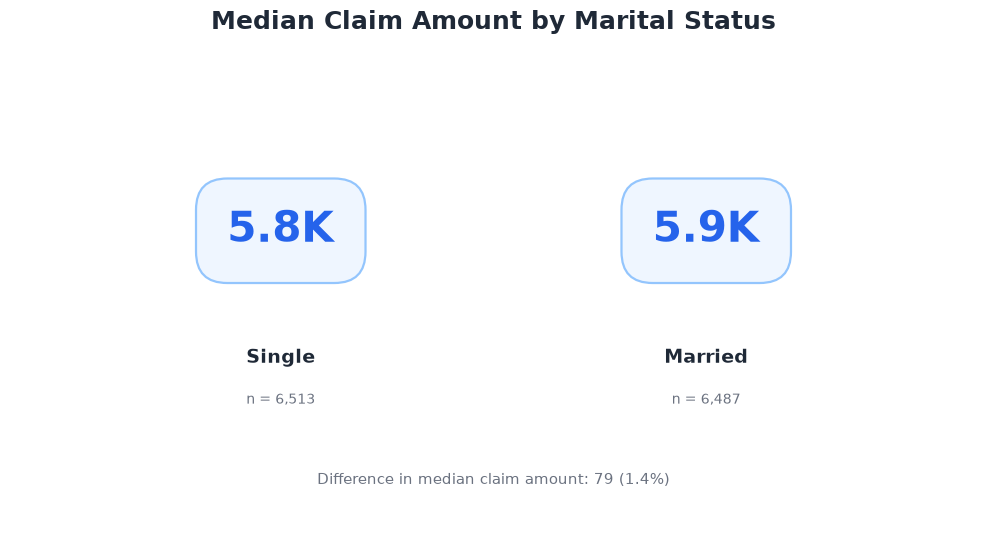

In [22]:
plot_claims_by_group(df, "Marital_Status")

In [23]:
show_key_insight(
    "Claim severity is relatively consistent across marital status categories. "
    "The observed differences are small, suggesting that marital status alone "
    "provides limited explanatory value for claim severity."
)

### Claim Amount by Education

In [24]:
summarize_claims_by_group(df, "Education")

,count,mean,median,std
Education,,,,
Master's,4383,9356.68,5854.0,15211.91
Bachelor's,4296,9170.02,5668.5,15390.18
PhD,4321,9027.70,5929.0,14510.60


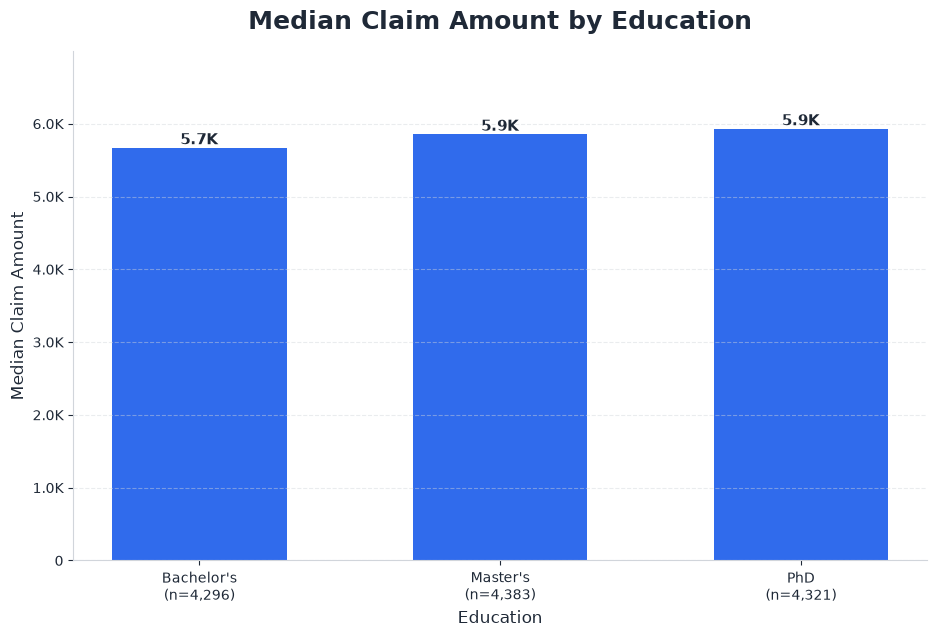

In [25]:
plot_claims_by_group(df, "Education")

In [26]:
show_key_insight(
    "Claim severity varies only modestly across education levels. "
    "The differences are limited, suggesting that education alone is not "
    "a strong explanation for claim severity."
)

### Claim Amount by Occupation

In [27]:
summarize_claims_by_group(df, "Occupation")

,count,mean,median,std
Occupation,,,,
Waiter,587,22761.66,7879.0,29042.50
Doctor,624,22040.64,7730.5,28106.85
Engineer,633,21685.85,7997.0,27739.65
Teacher,581,20251.78,7214.0,26348.89
CEO,10575,6317.31,5592.0,7516.19


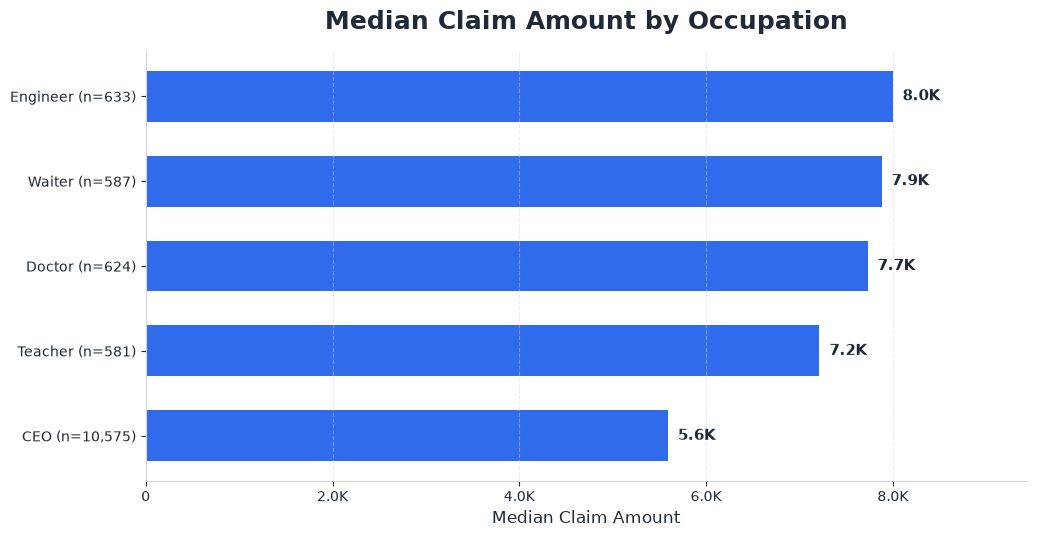

In [28]:
plot_claims_by_group(df, "Occupation")

In [29]:
show_business_finding(
    "Occupation shows greater variation in claim severity than gender, "
    "marital status, or education. However, the strong category imbalance "
    "means that these differences should not be used for operational decisions "
    "without additional data and statistical validation."
)

In [30]:
show_business_finding(
    "No single demographic or socioeconomic characteristic appears to be "
    "a strong driver of claim severity. Gender, marital status, and education "
    "show limited differences, while occupation shows greater variation but "
    "is affected by severe category imbalance."
)

## 10. Conclusions

### Data Quality

The dataset is structurally complete, with no missing values or duplicate records, and is suitable for exploratory analysis.

### Claim Distribution

Claim amounts are strongly right-skewed. A relatively small number of large claims contribute substantially to the overall distribution, making the median more representative than the mean when describing a typical claim.

### Numerical Relationships

Age and income show weak linear relationships with claim amount. Neither variable provides a strong standalone explanation for claim severity.

### Customer Group Comparisons

Gender, marital status, and education show only limited differences in typical claim amounts.

Occupation displays greater variation, but the severe imbalance in category sizes reduces the reliability of direct comparisons.

### Overall Business Conclusion

No single demographic or socioeconomic characteristic strongly explains claim severity in this dataset.

A more reliable insurance risk assessment would require additional information such as policy characteristics, coverage details, exposure data, historical claims, premiums, and customer identifiers.

## 11. Recommendations

The exploratory findings suggest several directions for improving future insurance analyses and supporting better business decisions.

In [31]:
show_business_finding(
    "Prioritize collecting policy-level information, historical claims, "
    "and customer identifiers to enable more reliable risk assessment.\n\n"
    "Future analyses should combine demographic variables with policy and "
    "behavioral information rather than relying on customer characteristics "
    "alone.\n\n"
    "Before making operational decisions, validate the observed differences "
    "using statistical hypothesis tests and larger, more balanced datasets."
)

## 12. Limitations

In [32]:
show_limitation(
    "The dataset is synthetic and its business definitions are not fully "
    "documented. Customer identifiers, policy details, premiums, deductibles, "
    "coverage limits, exposure information, and historical claims are unavailable.\n\n"
    "The occupation variable is highly imbalanced, the analysis is descriptive, "
    "and no statistical hypothesis tests were conducted. Therefore, the results "
    "should not be interpreted as causal or used directly for operational decisions."
)

## 13. Future Work

In [33]:
show_future_work(
    "Future work could include statistical hypothesis testing, predictive "
    "claim-severity models, customer segmentation, interaction analysis, "
    "and an interactive business dashboard.\n\n"
    "Additional policy, coverage, exposure, and historical claim information "
    "would also support more reliable insurance risk analysis."
)

## 14. Key Takeaways

In [34]:
show_business_finding(
    "The dataset is structurally complete, with no missing values or duplicate records."
)

In [35]:
show_key_insight(
    "Claim Amount is strongly right-skewed, making the median more representative than the mean."
)

In [36]:
show_key_insight(
    "Age and Income show weak linear relationships with claim severity."
)

In [37]:
show_business_finding(
    "Gender, Marital Status, and Education explain little variation in claim severity, while Occupation shows greater variation but suffers from severe category imbalance."
)

In [38]:
show_future_work(
    "Meaningful insurance risk modeling would require policy-level information, historical claims, and customer identifiers."
)